# Optimization + ML hybrid: full walkthrough

This notebook holds **all** implementation code. Run cells **top to bottom** from the repository root with your virtual environment as the Jupyter kernel.

**Contents:** (1) Environment — (2) Config — (3) Demand — (4) Forecasting — (5) LP — (6) Evaluation — (7) End-to-end run — (8) Analysis — (9) HTML report export.

**Data:** by default, **real** weekly demand from [UCI Online Retail](https://archive.ics.uci.edu/dataset/352/online+retail) (`config/experiment.yaml`: `data_source: uci_online_retail`). Set `data_source: synthetic` for the Poisson simulator. **Story:** multi-SKU demand — forecasts (seasonal naive, HGB on lags, last value, rolling mean) — linear inventory program (`planning_mode: batch` or `rolling`) — realized costs under **true** demand.

**In-notebook analysis:** section 8 prints styled tables, cost gaps vs oracle, stress results, and forecast error metrics (after section 7).

**Reports:** section 9 writes `report.html`, `outputs/report.html`, and `outputs/run_summary.json` when `export_html: true` in `config/experiment.yaml`. Long-form write-up: **`REPORT.md`**.

**Why not end-to-end RL?** Reinforcement learning fits when a trusted simulator and stable actions exist. Here we keep **auditable** linear constraints and explicit costs. RL is a natural extension later.

**Solvers:** PuLP with the bundled CBC LP engine (no paid licenses).


## 1. Environment

Create a venv, run `pip install -r requirements.txt` (includes **openpyxl** for the real retail Excel file), and select that interpreter as your Jupyter kernel. Uncomment `%pip` below only if something is missing.


In [1]:
# Uncomment if needed:
# %pip install pandas numpy scikit-learn pyyaml pulp matplotlib seaborn jinja2 openpyxl

from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
from typing import Any, Literal

import json
import numpy as np
import pandas as pd
import yaml
import matplotlib.pyplot as plt
import seaborn as sns
import pulp as pl
from datetime import UTC, datetime
from jinja2 import Environment, FileSystemLoader, select_autoescape


## 2. Config helpers

Experiment knobs and unit costs live in `config/experiment.yaml` and `config/costs.yaml`. The helper below loads them.


In [2]:
def load_yaml(path: Path | str) -> dict[str, Any]:
    p = Path(path)
    with p.open("r", encoding="utf-8") as f:
        return yaml.safe_load(f)


## 3. Demand data (real or synthetic)

**Config** (`config/experiment.yaml`) sets `data_source`:

- **`uci_online_retail`** (default): [UCI Online Retail](https://archive.ics.uci.edu/dataset/352/online+retail) — real transactions. We download the spreadsheet once into `data/raw/`, aggregate **units sold per StockCode per calendar week**, keep the top SKUs by volume, and encode weeks as integer periods `0 … T-1`.

- **`synthetic`**: the documented simulator below (Poisson demand, seasonality). Use this for a fully controlled lab or if you are offline.

Train vs test is always a **time cutoff** on periods (`train_period_fraction` in config).


In [3]:
import urllib.request


def load_uci_online_retail_long(
    root: Path,
    url: str,
    top_n_skus: int,
    min_distinct_weeks: int,
) -> pd.DataFrame:
    """Weekly demand panel from UCI Online Retail (real data). Columns: sku, period, demand."""
    raw = root / "data" / "raw"
    raw.mkdir(parents=True, exist_ok=True)
    dest = raw / "Online_Retail.xlsx"
    if not dest.is_file():
        urllib.request.urlretrieve(url, dest)
    retail = pd.read_excel(dest, engine="openpyxl")
    retail = retail.dropna(subset=["StockCode", "InvoiceDate"])
    retail = retail[retail["Quantity"] > 0].copy()
    retail["InvoiceDate"] = pd.to_datetime(retail["InvoiceDate"], errors="coerce")
    retail = retail.dropna(subset=["InvoiceDate"])
    retail["week"] = retail["InvoiceDate"].dt.to_period("W-SUN").dt.start_time
    agg = retail.groupby(["StockCode", "week"], as_index=False)["Quantity"].sum()
    vol = agg.groupby("StockCode")["Quantity"].sum().sort_values(ascending=False)
    top_codes = vol.head(top_n_skus).index.tolist()
    agg = agg[agg["StockCode"].isin(top_codes)].copy()
    weeks_sorted = sorted(agg['week'].unique())
    if len(weeks_sorted) < min_distinct_weeks:
        raise ValueError(
            f"After filtering, only {len(weeks_sorted)} distinct weeks "
            f"(need >= {min_distinct_weeks}). Lower uci_min_distinct_weeks or uci_top_n_skus."
        )
    week_to_idx = {w: i for i, w in enumerate(weeks_sorted)}
    code_to_sku = {c: i for i, c in enumerate(top_codes)}
    agg["sku"] = agg["StockCode"].map(code_to_sku)
    agg["period"] = agg["week"].map(week_to_idx)
    agg["demand"] = agg["Quantity"].clip(lower=0).astype(int)
    out = agg.groupby(["sku", "period"], as_index=False)["demand"].sum()
    return out[["sku", "period", "demand"]]


def generate_synthetic_demand(
    n_skus: int,
    n_periods: int,
    random_state: np.random.Generator | None = None,
) -> pd.DataFrame:
    rng = random_state or np.random.default_rng(42)
    rows: list[dict] = []
    for s in range(n_skus):
        level = rng.lognormal(mean=np.log(8 + s * 0.15), sigma=0.35)
        phase = rng.uniform(0, 2 * np.pi)
        for t in range(n_periods):
            season = 1.0 + 0.22 * np.sin(2 * np.pi * t / 52.0 + phase)
            noise = rng.lognormal(mean=0.0, sigma=0.12)
            mu = max(0.5, level * season * noise)
            d = rng.poisson(lam=float(mu))
            rows.append({"sku": s, "period": t, "demand": int(d)})
    return pd.DataFrame(rows)


def add_train_test_split(df: pd.DataFrame, train_period_fraction: float) -> pd.DataFrame:
    t_max = int(df["period"].max())
    cutoff = int(np.floor(train_period_fraction * (t_max + 1)))
    out = df.copy()
    out["split"] = np.where(out["period"] < cutoff, "train", "test")
    return out


## 4. Forecasting layer

- **Naive seasonal:** same week last year (or closest lag) per SKU.
- **ML:** `HistGradientBoostingRegressor` on lags (1, 2, 7, 14) and SKU id; recursive one-step forecasts on the test window.
- **Last value:** forecast at `t` equals realized demand at `t-1` (from history when available).
- **Rolling mean:** mean of the last `rolling_mean_window` periods strictly before `t`.

Configure which methods run via `forecast_suite` in `config/experiment.yaml` (`all`, `both`, `naive`, or `ml`). All methods return a **wide** matrix: periods × SKUs on the test horizon.


In [4]:
def pivot_from_long(long_df: pd.DataFrame) -> pd.DataFrame:
    return (
        long_df.pivot_table(index="period", columns="sku", values="demand", aggfunc="sum")
        .sort_index()
        .fillna(0.0)
    )


def _lags(s: pd.Series, periods: list[int]) -> pd.DataFrame:
    out = {}
    for p in periods:
        out[f"lag_{p}"] = s.shift(p)
    return pd.DataFrame(out)


@dataclass
class ForecastResult:
    name: str
    y_hat_wide: pd.DataFrame


def fit_naive_seasonal(
    train_wide: pd.DataFrame,
    test_index: pd.Index,
    season_length: int = 52,
) -> pd.DataFrame:
    preds = []
    for col in train_wide.columns:
        s = train_wide[col].astype(float)
        yhat = []
        for t in test_index:
            lag_idx = t - season_length
            if lag_idx in s.index:
                yhat.append(float(s.loc[lag_idx]))
            else:
                yhat.append(float(s.iloc[-min(len(s), season_length)]))
        preds.append(pd.Series(yhat, index=test_index, name=col))
    return pd.concat(preds, axis=1)


def fit_naive_last_value(train_wide: pd.DataFrame, test_index: pd.Index) -> pd.DataFrame:
    preds = []
    for col in train_wide.columns:
        s = train_wide[col].astype(float)
        yhat = []
        for t in test_index:
            lag_idx = t - 1
            if lag_idx in s.index:
                yhat.append(float(s.loc[lag_idx]))
            elif len(s) > 0:
                yhat.append(float(s.iloc[-1]))
            else:
                yhat.append(0.0)
        preds.append(pd.Series(yhat, index=test_index, name=col))
    return pd.concat(preds, axis=1)


def fit_rolling_mean(
    train_wide: pd.DataFrame, test_index: pd.Index, window: int
) -> pd.DataFrame:
    preds = []
    full_index = train_wide.index.union(test_index).sort_values()
    wide_full = train_wide.reindex(full_index).fillna(0.0)
    for col in train_wide.columns:
        s = wide_full[col].astype(float)
        yhat = []
        for t in test_index:
            hist = s.loc[s.index < t]
            tail = hist.tail(window)
            yhat.append(float(tail.mean()) if len(tail) else 0.0)
        preds.append(pd.Series(yhat, index=test_index, name=col))
    return pd.concat(preds, axis=1)


def build_supervised_from_long(
    long_df: pd.DataFrame,
    train_periods: set[int],
) -> tuple[pd.DataFrame, pd.Series]:
    parts = []
    for sku, g in long_df.groupby("sku"):
        g = g.sort_values("period")
        s = g.set_index("period")["demand"].astype(float)
        feat = _lags(s, [1, 2, 7, 14])
        feat["sku"] = float(sku)
        feat["period"] = g["period"].values
        feat["y"] = s.values
        parts.append(feat)
    Xy = pd.concat(parts, ignore_index=True)
    Xy = Xy.dropna()
    mask = Xy["period"].isin(train_periods)
    feature_cols = [c for c in Xy.columns if c not in ("y", "period")]
    X = Xy.loc[mask, feature_cols]
    y = Xy.loc[mask, "y"]
    return X, y


def predict_ml_test_periods(
    long_full: pd.DataFrame,
    train_periods: set[int],
    test_periods: list[int],
    random_state: int = 42,
) -> pd.DataFrame:
    from sklearn.ensemble import HistGradientBoostingRegressor

    test_periods = sorted(test_periods)
    sku_list = sorted(long_full["sku"].unique())
    wide_truth = pivot_from_long(long_full)
    sim = wide_truth.astype(float).copy()

    X_tr, y_tr = build_supervised_from_long(long_full, train_periods)
    model = HistGradientBoostingRegressor(
        max_depth=6,
        learning_rate=0.08,
        max_iter=200,
        random_state=random_state,
    )
    model.fit(X_tr, y_tr)

    preds: dict[int, dict[int, float]] = {}
    for t in test_periods:
        preds[t] = {}
        for sku in sku_list:
            row = {
                "lag_1": float(sim.loc[t - 1, sku]) if t - 1 in sim.index else 0.0,
                "lag_2": float(sim.loc[t - 2, sku]) if t - 2 in sim.index else 0.0,
                "lag_7": float(sim.loc[t - 7, sku]) if t - 7 in sim.index else 0.0,
                "lag_14": float(sim.loc[t - 14, sku]) if t - 14 in sim.index else 0.0,
                "sku": float(sku),
            }
            X_row = pd.DataFrame([row])
            yhat = float(model.predict(X_row)[0])
            preds[t][sku] = max(0.0, yhat)
        for sku in sku_list:
            sim.loc[t, sku] = preds[t][sku]

    out = pd.DataFrame(preds).T.sort_index()
    out.index.name = "period"
    out.columns = [int(c) for c in out.columns]
    return out


def run_forecast_suite(
    long_df: pd.DataFrame,
    train_period_fraction: float,
    kind: Literal["naive", "ml", "both", "all"] = "all",
    random_state: int = 42,
    rolling_mean_window: int = 8,
) -> dict[str, ForecastResult]:
    t_max = int(long_df["period"].max())
    cutoff = int(np.floor(train_period_fraction * (t_max + 1)))
    train_periods = set(range(0, cutoff))
    test_periods = list(range(cutoff, t_max + 1))
    wide = pivot_from_long(long_df)
    train_wide = wide.loc[wide.index < cutoff]
    test_idx = wide.loc[wide.index >= cutoff].index
    results: dict[str, ForecastResult] = {}

    if kind in ("naive", "both", "all"):
        naive = fit_naive_seasonal(train_wide, test_idx)
        results["naive"] = ForecastResult("naive_seasonal", naive)

    if kind in ("ml", "both", "all"):
        ml_wide = predict_ml_test_periods(long_df, train_periods, test_periods, random_state)
        results["ml"] = ForecastResult("hgb_lag", ml_wide)

    if kind == "all":
        results["last_value"] = ForecastResult(
            "last_value", fit_naive_last_value(train_wide, test_idx)
        )
        results["rolling_mean"] = ForecastResult(
            "rolling_mean", fit_rolling_mean(train_wide, test_idx, rolling_mean_window)
        )

    return results


## 5. Inventory LP (decision layer)

Multi-SKU, multi-period linear program: orders, end inventory, shortages; holding + variable ordering + shortage penalties; aggregate fill-rate constraint on **planning** demand; per-period order capacity. Fixed ordering costs are **not** in the LP (would need binaries); they are charged when simulating realized KPIs below.


In [5]:
@dataclass
class InventoryPlan:
    orders: pd.DataFrame
    inventory_end: pd.DataFrame
    shortage: pd.DataFrame
    objective_value: float
    status: str
    solver_name: str


def solve_inventory_lp(
    demand: pd.DataFrame,
    costs: dict[str, float],
    initial_inventory: float | dict[Any, float],
    min_fill_rate: float,
) -> InventoryPlan:
    demand = demand.astype(float).copy()
    periods = list(demand.index)
    skus = list(demand.columns)

    if isinstance(initial_inventory, dict):
        I0 = {s: float(initial_inventory[s]) for s in skus}
    else:
        I0 = {s: float(initial_inventory) for s in skus}

    h = float(costs["holding_per_unit_period"])
    c_var = float(costs["ordering_variable_per_unit"])
    c_short = float(costs["stockout_penalty_per_unit"])
    cap = float(costs["order_capacity_per_period"])

    prob = pl.LpProblem("inventory_lp", pl.LpMinimize)

    x: dict[tuple[Any, Any], pl.LpVariable] = {}
    Iend: dict[tuple[Any, Any], pl.LpVariable] = {}
    sht: dict[tuple[Any, Any], pl.LpVariable] = {}

    for t in periods:
        for s in skus:
            x[t, s] = pl.LpVariable(f"x_{t}_{s}", lowBound=0)
            Iend[t, s] = pl.LpVariable(f"I_{t}_{s}", lowBound=0)
            sht[t, s] = pl.LpVariable(f"u_{t}_{s}", lowBound=0)

    prob += pl.lpSum(
        h * Iend[t, s] + c_var * x[t, s] + c_short * sht[t, s] for t in periods for s in skus
    )

    for ti, t in enumerate(periods):
        prob += pl.lpSum(x[t, s] for s in skus) <= cap
        for s in skus:
            d = float(demand.loc[t, s])
            prob += sht[t, s] <= d
            if ti == 0:
                prev_i = I0[s]
            else:
                prev_i = Iend[periods[ti - 1], s]
            prob += Iend[t, s] == prev_i + x[t, s] - d + sht[t, s]

    total_demand = float(demand.to_numpy().sum())
    max_short = (1.0 - min_fill_rate) * total_demand
    prob += pl.lpSum(sht[t, s] for t in periods for s in skus) <= max_short

    solver = pl.PULP_CBC_CMD(msg=False, timeLimit=300)
    prob.solve(solver)
    status = pl.LpStatus[prob.status]

    orders = pd.DataFrame(
        [[pl.value(x[t, s]) or 0.0 for s in skus] for t in periods],
        index=periods,
        columns=skus,
    )
    inv = pd.DataFrame(
        [[pl.value(Iend[t, s]) or 0.0 for s in skus] for t in periods],
        index=periods,
        columns=skus,
    )
    sh = pd.DataFrame(
        [[pl.value(sht[t, s]) or 0.0 for s in skus] for t in periods],
        index=periods,
        columns=skus,
    )
    obj_val = float(pl.value(prob.objective) or 0.0)

    return InventoryPlan(
        orders=orders,
        inventory_end=inv,
        shortage=sh,
        objective_value=obj_val,
        status=status,
        solver_name="CBC_LP",
    )


solve_inventory_milp = solve_inventory_lp


## 6. Evaluation (simulation under true demand)

We build order plans using **forecast** demand in the LP, then roll the system forward with **true** demand to compute realized cost and fill rate. The oracle benchmark solves the LP on **true** demand for the test horizon.


In [6]:
@dataclass
class KPIReport:
    name: str
    total_cost: float
    fill_rate: float
    total_shortage: float
    total_demand: float


def simulate_orders_against_truth(
    orders: pd.DataFrame,
    demand_true: pd.DataFrame,
    initial_inventory: float | dict[int, float],
    costs: dict[str, float],
) -> KPIReport:
    demand_true = demand_true.astype(float).reindex_like(orders).fillna(0.0)
    periods = list(orders.index)
    skus = list(orders.columns)
    if isinstance(initial_inventory, dict):
        I0 = {s: float(initial_inventory[s]) for s in skus}
    else:
        I0 = {s: float(initial_inventory) for s in skus}

    h = float(costs["holding_per_unit_period"])
    c_var = float(costs["ordering_variable_per_unit"])
    c_fix = float(costs["ordering_fixed_per_order"])
    c_short = float(costs["stockout_penalty_per_unit"])

    I_prev = {s: I0[s] for s in skus}
    total_cost = 0.0
    total_short = 0.0
    total_d = 0.0

    for t in periods:
        for s in skus:
            x = max(0.0, float(orders.loc[t, s]))
            d = float(demand_true.loc[t, s])
            avail = I_prev[s] + x
            fulfilled = min(avail, d)
            sht = d - fulfilled
            I_prev[s] = avail - fulfilled
            total_short += sht
            total_d += d
            total_cost += h * I_prev[s]
            total_cost += c_var * x
            if x > 1e-8:
                total_cost += c_fix
            total_cost += c_short * sht

    fill = (total_d - total_short) / total_d if total_d > 0 else 1.0
    return KPIReport(
        name="simulated",
        total_cost=total_cost,
        fill_rate=float(fill),
        total_shortage=total_short,
        total_demand=total_d,
    )


def oracle_plan_and_kpis(
    demand_true: pd.DataFrame,
    costs: dict[str, float],
    initial_inventory: float,
    min_fill_rate: float,
) -> tuple[InventoryPlan, KPIReport]:
    plan = solve_inventory_milp(
        demand_true,
        costs,
        initial_inventory=initial_inventory,
        min_fill_rate=min_fill_rate,
    )
    kpi = simulate_orders_against_truth(
        plan.orders,
        demand_true,
        initial_inventory=initial_inventory,
        costs=costs,
    )
    kpi.name = "oracle_milp_truth"
    return plan, kpi


def scenario_kpi(
    label: str,
    demand_forecast: pd.DataFrame,
    demand_true: pd.DataFrame,
    costs: dict[str, float],
    initial_inventory: float,
    min_fill_rate: float,
) -> tuple[InventoryPlan, KPIReport]:
    plan = solve_inventory_milp(
        demand_forecast,
        costs,
        initial_inventory=initial_inventory,
        min_fill_rate=min_fill_rate,
    )
    kpi = simulate_orders_against_truth(
        plan.orders,
        demand_true,
        initial_inventory=initial_inventory,
        costs=costs,
    )
    kpi.name = label
    return plan, kpi


def rolling_scenario_kpi(
    label: str,
    demand_forecast: pd.DataFrame,
    demand_true: pd.DataFrame,
    costs: dict[str, float],
    initial_inventory: float,
    min_fill_rate: float,
    horizon: int,
) -> tuple[InventoryPlan | None, KPIReport]:
    demand_forecast = demand_forecast.astype(float).copy()
    demand_true = demand_true.astype(float).reindex_like(demand_forecast).fillna(0.0)
    periods = sorted(demand_true.index.tolist())
    skus = list(demand_true.columns)
    if isinstance(initial_inventory, dict):
        I0 = {s: float(initial_inventory[s]) for s in skus}
    else:
        I0 = {s: float(initial_inventory) for s in skus}
    I_prev = {s: I0[s] for s in skus}
    orders_rows: list[list[float]] = []
    last_plan: InventoryPlan | None = None
    for t in periods:
        t_end = min(t + horizon - 1, periods[-1])
        win = [p for p in periods if t <= p <= t_end]
        sub_hat = demand_forecast.loc[win, :]
        plan = solve_inventory_milp(sub_hat, costs, I_prev, min_fill_rate)
        last_plan = plan
        orders_rows.append([float(plan.orders.loc[t, s]) for s in skus])
        for s in skus:
            x = max(0.0, float(plan.orders.loc[t, s]))
            d = float(demand_true.loc[t, s])
            avail = I_prev[s] + x
            fulfilled = min(avail, d)
            I_prev[s] = avail - fulfilled
    orders = pd.DataFrame(orders_rows, index=periods, columns=skus)
    kpi = simulate_orders_against_truth(orders, demand_true, initial_inventory=I0, costs=costs)
    kpi.name = label
    return last_plan, kpi


def forecast_error_vs_truth(y_hat: pd.DataFrame, y_true: pd.DataFrame) -> tuple[float, float]:
    diff = (y_hat.astype(float) - y_true.astype(float)).to_numpy().ravel()
    mae = float(np.mean(np.abs(diff)))
    rmse = float(np.sqrt(np.mean(diff**2)))
    return mae, rmse


def stress_demand(demand: pd.DataFrame, factor: float) -> pd.DataFrame:
    return (demand.astype(float) * factor).clip(lower=0.0)


## 7. End-to-end run

Load config, build demand, fit forecasts, compare **oracle** vs forecast-driven LPs (`planning_mode: batch` or `rolling` in `config/experiment.yaml`), save CSVs and figures under `outputs/`, and run a stress sweep on the naive-based **batch** plan.


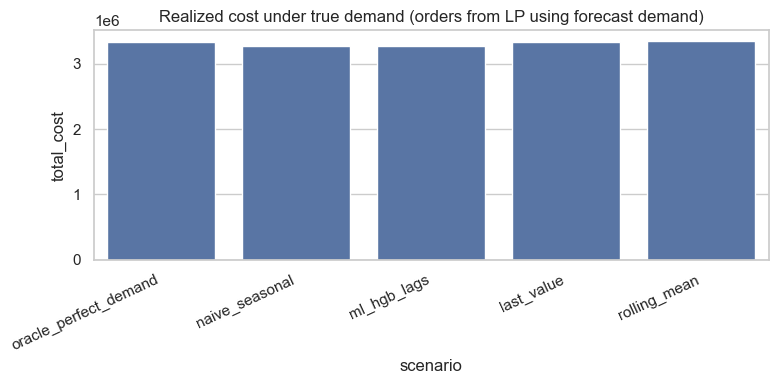

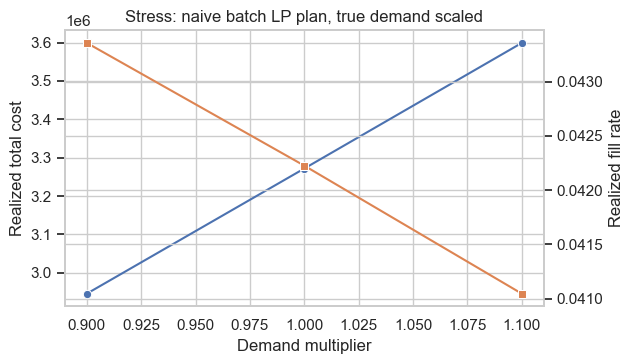

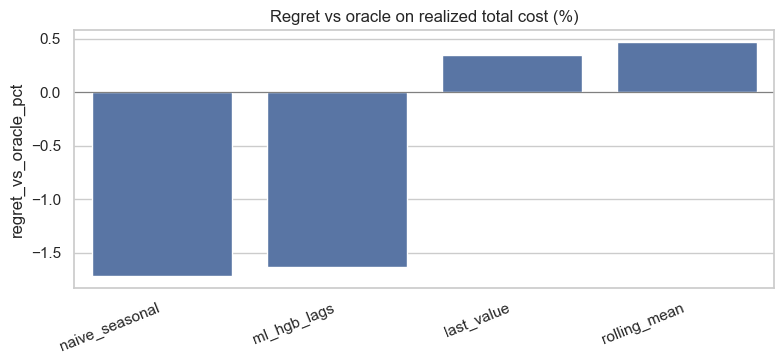

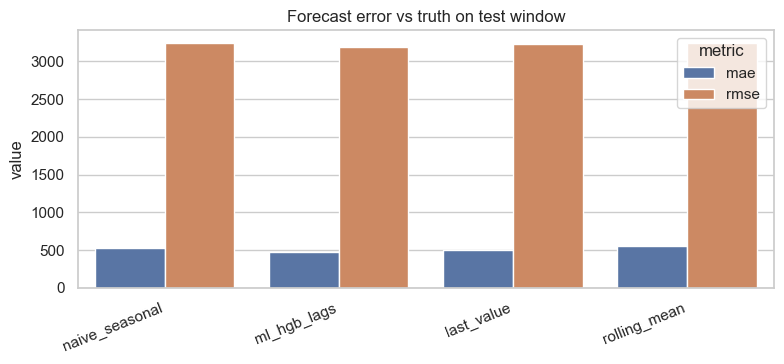

Saved CSVs, figures, and manifest under C:\Users\Jesco\Documents\GitHub\optimization-ml-hybrid\outputs


In [7]:
def find_repo_root() -> Path:
    p = Path.cwd().resolve()
    for _ in range(6):
        if (p / "config" / "costs.yaml").is_file():
            return p
        p = p.parent
    raise FileNotFoundError("Need config/costs.yaml — run Jupyter from the repository root.")


ROOT = find_repo_root()

if "load_yaml" not in globals():
    def load_yaml(path):
        p = Path(path)
        with p.open("r", encoding="utf-8") as f:
            return yaml.safe_load(f)

sns.set_theme(style="whitegrid")
OUT = ROOT / "outputs"
OUT.mkdir(parents=True, exist_ok=True)

exp = load_yaml(ROOT / "config" / "experiment.yaml")
costs = load_yaml(ROOT / "config" / "costs.yaml")
rng = np.random.default_rng(int(exp["random_seed"]))

ds = str(exp.get("data_source", "synthetic")).lower()
if ds == "uci_online_retail":
    long_df = load_uci_online_retail_long(
        ROOT,
        url=str(exp["uci_online_retail_url"]),
        top_n_skus=int(exp["uci_top_n_skus"]),
        min_distinct_weeks=int(exp.get("uci_min_distinct_weeks", 40)),
    )
elif ds == "synthetic":
    long_df = generate_synthetic_demand(
        int(exp["n_skus"]), int(exp["n_periods"]), random_state=rng
    )
else:
    raise ValueError(f"Unknown data_source: {ds!r}; use 'synthetic' or 'uci_online_retail'.")

long_df = add_train_test_split(long_df, float(exp["train_period_fraction"]))

wide = pivot_from_long(long_df)
cutoff = int(np.floor(float(exp["train_period_fraction"]) * (int(long_df["period"].max()) + 1)))
test_wide = wide.loc[wide.index >= cutoff]

suite = str(exp.get("forecast_suite", "all")).lower()
if suite not in ("all", "both", "naive", "ml"):
    suite = "all"
fc = run_forecast_suite(
    long_df,
    float(exp["train_period_fraction"]),
    kind=suite,
    random_state=int(exp["random_seed"]),
    rolling_mean_window=int(exp.get("rolling_mean_window", 8)),
)

forecast_maps: list[tuple[str, pd.DataFrame]] = []
for key, name in [
    ("naive", "naive_seasonal"),
    ("ml", "ml_hgb_lags"),
    ("last_value", "last_value"),
    ("rolling_mean", "rolling_mean"),
]:
    if key in fc:
        hat = fc[key].y_hat_wide.reindex_like(test_wide).fillna(0.0)
        forecast_maps.append((name, hat))

min_fr = float(exp["min_fill_rate"])
I0 = float(costs["initial_inventory"])
planning_mode = str(exp.get("planning_mode", "batch")).lower()
roll_h = int(exp.get("rolling_horizon_periods", 13))

rows = []
dm_rows = []
oracle_plan, oracle_kpi = oracle_plan_and_kpis(test_wide, costs, I0, min_fr)
rows.append(
    {"scenario": "oracle_perfect_demand", "total_cost": oracle_kpi.total_cost, "fill_rate": oracle_kpi.fill_rate}
)
oa_mae, oa_rmse = forecast_error_vs_truth(test_wide, test_wide)
dm_rows.append(
    {
        "scenario": "oracle_perfect_demand",
        "mae": oa_mae,
        "rmse": oa_rmse,
        "regret_vs_oracle_pct": 0.0,
    }
)

oracle_cost = oracle_kpi.total_cost

for label, dhat in forecast_maps:
    if planning_mode == "rolling":
        plan, kpi = rolling_scenario_kpi(
            label, dhat, test_wide, costs, I0, min_fr, roll_h
        )
    else:
        plan, kpi = scenario_kpi(label, dhat, test_wide, costs, I0, min_fr)
    rows.append({"scenario": label, "total_cost": kpi.total_cost, "fill_rate": kpi.fill_rate})
    mae, rmse = forecast_error_vs_truth(dhat, test_wide)
    regret = (kpi.total_cost - oracle_cost) / oracle_cost * 100 if oracle_cost else 0.0
    dm_rows.append(
        {"scenario": label, "mae": mae, "rmse": rmse, "regret_vs_oracle_pct": regret}
    )

summary = pd.DataFrame(rows)
summary.to_csv(OUT / "kpi_comparison.csv", index=False)

decision_metrics = pd.DataFrame(dm_rows)
decision_metrics.to_csv(OUT / "decision_metrics.csv", index=False)

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=summary, x="scenario", y="total_cost", ax=ax)
ax.set_title("Realized cost under true demand (orders from LP using forecast demand)")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
fig.savefig(OUT / "cost_by_scenario.png", dpi=150)
plt.show()
plt.close(fig)

naive_hat = fc["naive"].y_hat_wide.reindex_like(test_wide).fillna(0.0) if "naive" in fc else None

stress_rows = []
if naive_hat is not None:
    for m in exp["stress_multipliers"]:
        d_stress = stress_demand(test_wide, float(m))
        _, k = scenario_kpi(f"naive_stress_x{m}", naive_hat, d_stress, costs, I0, min_fr)
        stress_rows.append({"multiplier": m, "total_cost": k.total_cost, "fill_rate": k.fill_rate})
stress_summary = pd.DataFrame(stress_rows)
stress_summary.to_csv(OUT / "sensitivity_naive_forecast.csv", index=False)

if len(stress_summary) > 0:
    fig2, ax2 = plt.subplots(figsize=(6.5, 3.8))
    ax2_t = ax2.twinx()
    sns.lineplot(data=stress_summary, x="multiplier", y="total_cost", marker="o", ax=ax2, color="C0")
    sns.lineplot(data=stress_summary, x="multiplier", y="fill_rate", marker="s", ax=ax2_t, color="C1")
    ax2.set_title("Stress: naive batch LP plan, true demand scaled")
    ax2.set_xlabel("Demand multiplier")
    ax2.set_ylabel("Realized total cost")
    ax2_t.set_ylabel("Realized fill rate")
    plt.tight_layout()
    fig2.savefig(OUT / "sensitivity_naive_cost.png", dpi=150)
    plt.show()
    plt.close(fig2)

dm_plot = decision_metrics[~decision_metrics["scenario"].str.contains("oracle", case=False)].copy()
if len(dm_plot) > 0:
    fig3, ax3 = plt.subplots(figsize=(8, 3.8))
    sns.barplot(data=dm_plot, x="scenario", y="regret_vs_oracle_pct", ax=ax3)
    ax3.axhline(0, color="gray", lw=0.8)
    ax3.set_title("Regret vs oracle on realized total cost (%)")
    ax3.set_xlabel("")
    plt.xticks(rotation=22, ha="right")
    plt.tight_layout()
    fig3.savefig(OUT / "decision_regret_vs_oracle.png", dpi=150)
    plt.show()
    plt.close(fig3)

    fe_m = dm_plot.melt(id_vars=["scenario"], value_vars=["mae", "rmse"], var_name="metric", value_name="value")
    fig4, ax4 = plt.subplots(figsize=(8, 3.8))
    sns.barplot(data=fe_m, x="scenario", y="value", hue="metric", ax=ax4)
    ax4.set_title("Forecast error vs truth on test window")
    ax4.set_xlabel("")
    plt.xticks(rotation=22, ha="right")
    plt.tight_layout()
    fig4.savefig(OUT / "forecast_error_mae_rmse.png", dpi=150)
    plt.show()
    plt.close(fig4)

with open(OUT / "run_manifest.json", "w", encoding="utf-8") as f:
    json.dump(
        {
            "n_skus": int(long_df["sku"].nunique()),
            "n_periods": int(long_df["period"].nunique()),
            "cutoff": cutoff,
            "data_source": str(exp.get("data_source", "synthetic")),
            "planning_mode": planning_mode,
            "rolling_horizon_periods": roll_h,
            "forecast_suite": suite,
        },
        f,
        indent=2,
    )

print("Saved CSVs, figures, and manifest under", OUT.resolve())


## 8. Results and analysis

After running section 7, use this section for **tables and interpretation**. The same numbers are saved under `outputs/`.


In [8]:
from IPython.display import display, Markdown

display(
    Markdown(
        "**Realized total cost and fill rate** (orders from the LP built on forecast or oracle demand; simulation uses **true** test demand)."
    )
)
display(summary.style.format({"total_cost": "{:,.2f}", "fill_rate": "{:.4f}"}).hide(axis="index"))

oracle_cost = float(
    summary.loc[summary["scenario"].str.contains("oracle", case=False), "total_cost"].iloc[0]
)
lines = ["**Cost gap vs oracle (percent)**", ""]
for _, r in summary.iterrows():
    if "oracle" in r["scenario"].lower():
        continue
    gap = (float(r["total_cost"]) - oracle_cost) / oracle_cost * 100
    lines.append(
        f"- {r['scenario']}: **{gap:+.1f}%** (realized cost {float(r['total_cost']):,.2f}, fill {float(r['fill_rate']):.4f})"
    )
display(Markdown(chr(10).join(lines)))

dm_path = OUT / "decision_metrics.csv"
if dm_path.is_file():
    dm = pd.read_csv(dm_path)
    display(Markdown("**Forecast error vs truth (test window) and regret**"))
    display(
        dm.style.format(
            {
                "mae": "{:.4f}",
                "rmse": "{:.4f}",
                "regret_vs_oracle_pct": "{:+.2f}",
            }
        ).hide(axis="index")
    )

display(
    Markdown(
        "**Stress test:** same naive-based order rule (batch LP); **true** demand scaled by the multiplier."
    )
)
display(
    stress_summary.style.format(
        {"multiplier": "{:.1f}", "total_cost": "{:,.2f}", "fill_rate": "{:.4f}"}
    ).hide(axis="index")
)

display(
    Markdown(
        """**How to read this**

- **Oracle** is a perfect-foresight benchmark on the **test window** (true demand inside the LP).
- **Forecast scenarios** put `d_hat` into the LP (batch or rolling per config); realized cost and fill use **truth**.
- **Stress** moves true demand without refitting forecasts.

**Figures (Section 7, under `outputs/`):** `cost_by_scenario.png` ranks realized cost; `decision_regret_vs_oracle.png` shows regret vs oracle (%); `forecast_error_mae_rmse.png` compares statistical error; `sensitivity_naive_cost.png` plots cost and fill vs demand multiplier for a fixed naive plan. **`REPORT.md`** and **`report.html`** explain each chart in prose.

Tweak `config/experiment.yaml` or the RNG seed and re-run sections 7 through 9 to explore."""
    )
)


**Realized total cost and fill rate** (orders from the LP built on forecast or oracle demand; simulation uses **true** test demand).

scenario,total_cost,fill_rate
oracle_perfect_demand,"3,328,858.25",0.0270
naive_seasonal,"3,271,715.00",0.0422
ml_hgb_lags,"3,274,647.89",0.0400
last_value,"3,340,406.00",0.0264
rolling_mean,"3,344,529.66",0.0158


**Cost gap vs oracle (percent)**

- naive_seasonal: **-1.7%** (realized cost 3,271,715.00, fill 0.0422)
- ml_hgb_lags: **-1.6%** (realized cost 3,274,647.89, fill 0.0400)
- last_value: **+0.3%** (realized cost 3,340,406.00, fill 0.0264)
- rolling_mean: **+0.5%** (realized cost 3,344,529.66, fill 0.0158)

**Forecast error vs truth (test window) and regret**

scenario,mae,rmse,regret_vs_oracle_pct
oracle_perfect_demand,0.0000,0.0000,+0.00
naive_seasonal,525.0045,3244.5819,-1.72
ml_hgb_lags,470.0417,3195.1023,-1.63
last_value,495.6384,3226.1873,+0.35
rolling_mean,551.0606,3248.1142,+0.47


**Stress test:** same naive-based order rule (batch LP); **true** demand scaled by the multiplier.

multiplier,total_cost,fill_rate
0.9,"2,945,405.70",0.0434
1.0,"3,271,715.00",0.0422
1.1,"3,599,179.22",0.0410


**How to read this**

- **Oracle** is a perfect-foresight benchmark on the **test window** (true demand inside the LP).
- **Forecast scenarios** put `d_hat` into the LP (batch or rolling per config); realized cost and fill use **truth**.
- **Stress** moves true demand without refitting forecasts.

**Figures (Section 7, under `outputs/`):** `cost_by_scenario.png` ranks realized cost; `decision_regret_vs_oracle.png` shows regret vs oracle (%); `forecast_error_mae_rmse.png` compares statistical error; `sensitivity_naive_cost.png` plots cost and fill vs demand multiplier for a fixed naive plan. **`REPORT.md`** and **`report.html`** explain each chart in prose.

Tweak `config/experiment.yaml` or the RNG seed and re-run sections 7 through 9 to explore.

## 9. HTML report and run summary

Writes Engineering Systems Design style **`outputs/report.html`**, **`report.html`** at the repo root, and **`outputs/run_summary.json`**. Set `export_html: false` in `config/experiment.yaml` to skip (for example in faster CI).


In [9]:
if "ROOT" not in globals():
    ROOT = find_repo_root()

def build_esd_html_report(root: Path) -> None:
    ROOT = root
    OUT = ROOT / "outputs"
    TEMPLATE_DIR = ROOT / "reports" / "templates"
    exp = load_yaml(ROOT / "config" / "experiment.yaml")
    costs = load_yaml(ROOT / "config" / "costs.yaml")

    kpi_path = OUT / "kpi_comparison.csv"
    sens_path = OUT / "sensitivity_naive_forecast.csv"
    manifest_path = OUT / "run_manifest.json"

    if not kpi_path.is_file():
        raise FileNotFoundError(f"Missing {kpi_path}. Run the notebook or pipeline first.")

    kpi = pd.read_csv(kpi_path)
    sensitivity = pd.read_csv(sens_path) if sens_path.is_file() else pd.DataFrame()
    manifest: dict = {}
    if manifest_path.is_file():
        manifest = json.loads(manifest_path.read_text(encoding="utf-8"))

    kpi_rows = kpi.to_dict(orient="records")
    sens_rows = sensitivity.to_dict(orient="records") if len(sensitivity) else []

    seed = exp.get("random_seed", "")
    n_skus = manifest.get("n_skus", exp.get("n_skus"))
    n_periods = manifest.get("n_periods", exp.get("n_periods"))
    cutoff = manifest.get("cutoff", "")

    oracle_cost = kpi.loc[kpi["scenario"].str.contains("oracle", case=False), "total_cost"]
    oracle_cost = float(oracle_cost.iloc[0]) if len(oracle_cost) else 0.0
    naive_cost = float(kpi.loc[kpi["scenario"].str.contains("naive", case=False), "total_cost"].iloc[0])
    ml_cost = float(kpi.loc[kpi["scenario"].str.contains("ml", case=False), "total_cost"].iloc[0])

    gap_naive = (naive_cost - oracle_cost) / oracle_cost * 100 if oracle_cost else 0.0
    gap_ml = (ml_cost - oracle_cost) / oracle_cost * 100 if oracle_cost else 0.0

    data_source = str(manifest.get("data_source", exp.get("data_source", "synthetic")))

    if gap_naive >= 0 and gap_ml >= 0:
        cost_bullet = (
            f"Oracle planning with perfect test demand in the LP ({oracle_cost:,.0f} realized cost) "
            f"is below forecast-driven plans; naive and ML are about "
            f"{gap_naive:+.1f}% and {gap_ml:+.1f}% vs oracle on realized total cost."
        )
    elif gap_naive <= 0 and gap_ml <= 0:
        cost_bullet = (
            f"Realized total cost is lower for naive ({naive_cost:,.0f}) and ML ({ml_cost:,.0f}) than "
            f"for the perfect-foresight LP plan ({oracle_cost:,.0f}), about "
            f"{gap_naive:.1f}% and {gap_ml:.1f}% vs oracle. The LP objective omits per-order fixed "
            "costs; the simulator adds them, so ranking by realized KPIs need not match the LP optimum."
        )
    else:
        cost_bullet = (
            f"Oracle realized cost {oracle_cost:,.0f}; naive {naive_cost:,.0f} ({gap_naive:+.1f}% vs oracle); "
            f"ML {ml_cost:,.0f} ({gap_ml:+.1f}% vs oracle). Mixed ranking reflects objective mismatch "
            "between LP and simulation."
        )

    executive_bullets = [
        cost_bullet,
        (
            "Realized fill rate can sit far below the nominal LP service target because the aggregate "
            "fill constraint binds on planning demand (forecast or truth in the LP), not on realized demand."
        ),
        (
            "Stress multipliers on true demand move total cost and fill rate without re-fitting "
            "forecasts, illustrating sensitivity of a fixed plan under scale misspecification."
        ),
    ]

    system_framing = (
        "Actors: a planner chooses periodic replenishment orders subject to a warehouse capacity. "
        "Customers draw true demand; the planner only sees history when fitting forecasts. "
        "Feedback is monetary: holding, variable ordering, fixed ordering (in simulation), and stockouts."
    )

    system_rows = [
        {
            "layer": "Prediction",
            "description": (
                "Seasonal naive and lag-feature gradient boosting produce test-horizon planning demand matrices."
            ),
        },
        {
            "layer": "Optimization",
            "description": (
                "A multi-SKU LP minimizes holding plus variable ordering plus shortage penalties with "
                "aggregate fill and per-period capacity."
            ),
        },
        {
            "layer": "Evaluation",
            "description": (
                "Oracle uses truth in the LP; forecast scenarios use d_hat in the LP, then simulate realized "
                "cost and fill under true demand with fixed orders."
            ),
        },
    ]

    if data_source == "uci_online_retail":
        methods_lines = [
            (
                "Data: UCI Online Retail (UK transactions), aggregated to weekly units per StockCode; "
                f"top SKUs by volume, encoded as {n_skus} SKUs × {n_periods} weekly periods."
            ),
            f"Train fraction {exp['train_period_fraction']:.0%}; test horizon from period {cutoff} onward.",
            f"LP service target: minimum aggregate fill rate ≥ {exp['min_fill_rate']:.0%} on planning demand.",
            "Solver: PuLP with bundled CBC (no commercial licenses). Fixed ordering charged in simulation only.",
        ]
    else:
        methods_lines = [
            (
                f"Synthetic DGP: per-SKU log-normal level, sinusoidal seasonality, Poisson demand "
                f"({n_skus} SKUs, {n_periods} periods)."
            ),
            f"Train fraction {exp['train_period_fraction']:.0%}; test horizon from period {cutoff} onward.",
            f"LP service target: minimum aggregate fill rate ≥ {exp['min_fill_rate']:.0%} on planning demand.",
            "Solver: PuLP with bundled CBC (no commercial licenses). Fixed ordering charged in simulation only.",
        ]

    if data_source == "uci_online_retail":
        subtitle = (
            "Predict-then-optimize inventory pipeline · UCI Online Retail weekly panel · realized KPIs under true demand"
        )
    else:
        subtitle = (
            "Predict-then-optimize inventory pipeline · synthetic retail panel · realized KPIs under true demand"
        )

    pto_caveat = (
        "Plug-in forecasts optimize a statistical loss that need not align with ordering cost. "
        "A stronger forecast can lose to a naive one on realized inventory cost in finite samples."
    )

    figure_path = OUT / "cost_by_scenario.png"
    figure_rel_outputs = "cost_by_scenario.png" if figure_path.is_file() else None
    figure_rel_root = "outputs/cost_by_scenario.png" if figure_path.is_file() else None
    p_stress = OUT / "sensitivity_naive_cost.png"
    figure_stress_rel_outputs = "sensitivity_naive_cost.png" if p_stress.is_file() else None
    figure_stress_rel_root = "outputs/sensitivity_naive_cost.png" if p_stress.is_file() else None
    p_regret = OUT / "decision_regret_vs_oracle.png"
    figure_regret_rel_outputs = "decision_regret_vs_oracle.png" if p_regret.is_file() else None
    figure_regret_rel_root = "outputs/decision_regret_vs_oracle.png" if p_regret.is_file() else None
    p_fe = OUT / "forecast_error_mae_rmse.png"
    figure_forecast_err_rel_outputs = "forecast_error_mae_rmse.png" if p_fe.is_file() else None
    figure_forecast_err_rel_root = "outputs/forecast_error_mae_rmse.png" if p_fe.is_file() else None

    tau = float(exp["min_fill_rate"])
    cap = costs.get("order_capacity_per_period", "")

    data_source_label = (
        "UCI Online Retail (weekly aggregate)" if data_source == "uci_online_retail" else "Synthetic Poisson panel"
    )

    cost_rows = [{"parameter": k, "value": str(v)} for k, v in costs.items()]

    stakeholder_rows = [
        {
            "stakeholder": "Planner / operations",
            "need": "Periodic replenishment under warehouse capacity; minimize holding, variable ordering, and shortage costs in the LP; evaluate with full cost stack in simulation.",
        },
        {
            "stakeholder": "Service policy owner",
            "need": f"Aggregate fill target on planning demand at least {tau:.0%} (configurable τ).",
        },
        {
            "stakeholder": "Analysis and audit",
            "need": "Documented LP, open-source CBC solver, single-notebook implementation for traceability.",
        },
    ]

    requirement_rows = [
        {
            "id": "FR-1",
            "requirement": "Multi-SKU, multi-period inventory balance with nonnegative orders, inventory, and shortages.",
            "metric": "Notebook `solve_inventory_lp` balance rows",
        },
        {
            "id": "FR-2",
            "requirement": f"Minimum aggregate fill on planning demand: total shortage ≤ (1−τ) × total planning demand, τ = {tau:.0%}.",
            "metric": "LP aggregate shortage constraint",
        },
        {
            "id": "FR-3",
            "requirement": f"Total order quantity per period ≤ {cap} units (all SKUs combined).",
            "metric": "LP capacity constraint per t",
        },
        {
            "id": "NFR-1",
            "requirement": "No commercial solver dependency.",
            "metric": "PuLP + CBC",
        },
    ]

    traceability_rows = [
        {"req": "FR-1", "artifact": "`solve_inventory_lp`: per (t,s) balance I_end = I_prev + x − d_plan + u; u ≤ d_plan."},
        {"req": "FR-2", "artifact": f"Single row: Σ u ≤ (1−{tau:.2f}) × Σ d_plan over test horizon."},
        {"req": "FR-3", "artifact": "Per period: Σ_s x[t,s] ≤ order_capacity_per_period."},
        {"req": "NFR-1", "artifact": "`pl.PULP_CBC_CMD` in notebook."},
    ]

    report_title = "Predict-then-optimize for multi-SKU inventory"

    problem_statement = (
        "Retail and distribution systems must place replenishment orders before demand is realized. "
        "Decisions are informed by forecasts, yet performance is judged on outcomes under true demand. "
        "This report documents a decomposed system: forecasting, linear optimization with service and capacity "
        "constraints, and ex-post simulation for realized cost and fill."
    )
    need_statement = (
        "The need is traceable evidence of how forecast-driven plans behave relative to a perfect-foresight "
        "benchmark, including sensitivity to demand scale, under explicit unit economics and capacity limits."
    )

    scope_lines = [
        "Single echelon: one planning pool with a shared per-period order capacity (no multi-node network).",
        "Continuous order quantities in the LP; no lot sizing or lead-time delays beyond the period index.",
        "Point forecasts only; no joint demand distribution in the optimization layer.",
        "Implementation lives in `optimization_ml_hybrid_walkthrough.ipynb`; config in `config/*.yaml`.",
    ]

    exec_purpose = (
        "Satisfy engineering review-style documentation: problem, stakeholders, requirements with traceability, "
        "architecture, detailed design (data, forecasts, LP, simulation), results, sensitivity, risks, and reproducibility."
    )

    architecture_intro = (
        "The system is decomposed into three subsystems. Information flows one way into the LP at decision time; "
        "truth enters only in the evaluation module (or inside the LP for the oracle benchmark)."
    )

    information_flow_diagram = (
        "  Training-period demand history\n"
        "           │\n"
        "           ▼\n"
        "  ┌────────────────────┐      planning demand d_plan\n"
        "  │ Forecast subsystem │  (d_hat from naive or ML, or d_true for oracle)\n"
        "  └─────────┬──────────┘\n"
        "            │\n"
        "            ▼\n"
        "  ┌────────────────────┐      orders x[t,s] ≥ 0\n"
        "  │  LP (CBC)        │      min Σ (h·I + c_var·x + c_short·u)\n"
        "  │  min cost        │      s.t. balance, capacity, aggregate fill on d_plan\n"
        "  └─────────┬────────┘\n"
        "            │\n"
        "            ▼\n"
        "  ┌────────────────────┐      true demand d_true (test horizon)\n"
        "  │ Simulation / KPIs  │      realized cost (incl. fixed order cost), fill rate\n"
        "  └────────────────────┘"
    )

    if data_source == "uci_online_retail":
        data_pipeline_paragraph = (
            "Real transaction data from the UCI Online Retail repository are downloaded once to `data/raw/`, "
            "read with `openpyxl`, filtered to positive quantities, and aggregated to calendar-week units sold per "
            "`StockCode`. The top SKUs by total volume are retained, weeks are sorted and indexed 0…T−1, and the "
            "panel is expressed in long form then pivoted to wide for modeling. Missing SKU-week pairs are treated "
            "as zero demand in the wide matrix."
        )
    else:
        data_pipeline_paragraph = (
            "Synthetic demand is generated in the notebook via a documented stochastic process (heterogeneous "
            "levels, seasonality, Poisson sampling). The same long-to-wide pipeline applies."
        )

    forecast_detail_lines = [
        (
            "**Seasonal naive:** for each SKU, demand at test period t is forecast using the same seasonal lag "
            "(e.g. week t−52) when available in training; otherwise the closest prior lag."
        ),
        (
            "**ML (HGB):** `HistGradientBoostingRegressor` on features including lags 1, 2, 7, 14 and an encoded "
            "SKU index; trained on training periods only; recursive one-step predictions over the test window."
        ),
        (
            "**Last value:** forecast at t equals realized demand at t−1 from the historical series."
        ),
        (
            "**Rolling mean:** mean of the last K periods strictly before t (K from config `rolling_mean_window`)."
        ),
    ]

    lp_intro = (
        "The optimization layer is a linear program over the test horizon indices present in the planning demand "
        "matrix. Indices t and s refer to period and SKU; d_plan[t,s] is the planning demand (forecast or truth)."
    )

    lp_rows = [
        {
            "element": "Decision variables",
            "spec": (
                "x[t,s] ≥ 0 order quantity; I_end[t,s] ≥ 0 end-of-period inventory; u[t,s] ≥ 0 shortage "
                "(unmet demand in the LP accounting)."
            ),
        },
        {
            "element": "Objective",
            "spec": (
                "Minimize Σ_{t,s} ( h·I_end + c_var·x + c_short·u ) using `holding_per_unit_period`, "
                "`ordering_variable_per_unit`, `stockout_penalty_per_unit` from config."
            ),
        },
        {
            "element": "Inventory balance",
            "spec": (
                "I_end[t,s] = I_prev + x[t,s] − d_plan[t,s] + u[t,s]; first period uses `initial_inventory` per SKU."
            ),
        },
        {
            "element": "Local shortage bound",
            "spec": "u[t,s] ≤ d_plan[t,s] for each (t,s).",
        },
        {
            "element": "Order capacity",
            "spec": "Σ_s x[t,s] ≤ order_capacity_per_period for each t.",
        },
        {
            "element": "Aggregate service",
            "spec": (
                f"Sum over all (t,s) of u ≤ (1−τ) × sum of d_plan with τ = {tau:.2f} "
                "(minimum fill on planning demand)."
            ),
        },
    ]

    lp_aggregate_fill = (
        "The aggregate constraint limits total **planned** shortage relative to total **planning** demand. "
        "It does not bound realized shortage against true demand; hence realized fill rate in §6 can differ sharply "
        "from τ when d_plan and d_true disagree."
    )

    c_fix = costs.get("ordering_fixed_per_order", 0)

    simulation_metric_rows = [
        {
            "metric": "Realized total cost",
            "definition": (
                "Roll forward with true demand: end-of-period holding at rate h, variable cost c_var per unit "
                f"ordered, stockout penalty c_short per unmet unit, plus fixed cost {c_fix} per (t,s) when x[t,s] > 0. "
                "Same orders as the LP output."
            ),
        },
        {
            "metric": "Realized fill rate",
            "definition": (
                "(Total true demand − total unmet demand) / total true demand over the simulated horizon, "
                "with unmet demand computed period by period from inventory and orders."
            ),
        },
    ]

    oracle_fr = float(kpi.loc[kpi["scenario"].str.contains("oracle", case=False), "fill_rate"].iloc[0])
    naive_fr = float(kpi.loc[kpi["scenario"].str.contains("naive", case=False), "fill_rate"].iloc[0])
    ml_fr = float(kpi.loc[kpi["scenario"].str.contains("ml", case=False), "fill_rate"].iloc[0])

    results_interpretation = (
        f"Numerical results: oracle realized cost {oracle_cost:,.2f} (fill {oracle_fr:.4f}); "
        f"naive {naive_cost:,.2f} ({gap_naive:+.2f}% vs oracle, fill {naive_fr:.4f}); "
        f"ML {ml_cost:,.2f} ({gap_ml:+.2f}% vs oracle, fill {ml_fr:.4f}). "
    )
    if gap_naive <= 0 and gap_ml <= 0:
        results_interpretation += (
            "Both forecast-driven plans achieve lower **simulated** total cost than the oracle in this build. "
            "Interpret this as an objective mismatch: the LP minimizes linear holding, variable ordering, and "
            "shortage costs without fixed ordering charges, while the simulator adds fixed costs per placement. "
            "The oracle LP is still optimal for its stated LP objective on planning demand; it is not guaranteed "
            "to minimize the simulator’s objective."
        )
    elif gap_naive >= 0 and gap_ml >= 0:
        results_interpretation += (
            "Forecast-driven plans exceed oracle cost on realized KPIs in this build, which is the typical "
            "ordering when the simulation cost structure aligns more closely with the LP tradeoffs."
        )
    else:
        results_interpretation += (
            "Mixed ranking between naive and ML relative to oracle indicates scenario-specific interaction "
            "between forecast shape, capacity, and penalties."
        )
    results_interpretation += (
        f" Realized fill rates remain well below τ={tau:.0%} because τ constrains the LP on planning demand, "
        "not on out-of-sample truth."
    )

    sensitivity_intro = (
        "A stress test scales **true** demand by a multiplier while holding the order plan from the naive "
        "forecast LP at multiplier 1.0. This isolates exposure to demand level misspecification without re-solving "
        "the optimization or re-estimating forecasts."
    )

    figure_cost_analysis = (
        "Bars compare scenarios on realized total cost after simulating LP orders under true demand. "
        "Read alongside the KPI table: bar height encodes the simulator objective (holding, variable and fixed "
        "ordering, stockouts), which can diverge from LP-only optimality when fixed costs appear only in simulation."
    )
    figure_regret_analysis = (
        "Regret is (realized cost minus oracle realized cost) divided by oracle cost, in percent. "
        "Negative bars mean the forecast-driven plan beat the oracle on this simulator in this split (often due to "
        "objective mismatch); positive bars mean higher realized cost than the perfect-foresight LP plan."
    )
    figure_forecast_err_analysis = (
        "MAE and RMSE aggregate point forecast error versus true test demand (as defined in the notebook). "
        "Lower statistical error does not guarantee lower regret: ML can show better RMSE than naive yet similar or "
        "worse realized cost, which is the predict-then-optimize gap this study highlights."
    )
    if len(sens_rows) >= 2:
        sens_sorted = sorted(sens_rows, key=lambda r: float(r["multiplier"]))
        m_lo = sens_sorted[0]["multiplier"]
        m_hi = sens_sorted[-1]["multiplier"]
        c_lo = float(sens_sorted[0]["total_cost"])
        c_hi = float(sens_sorted[-1]["total_cost"])
        figure_sensitivity_analysis = (
            f"The dual-axis chart matches the stress table: from multiplier {m_lo} to {m_hi}, realized total cost "
            f"moves from about {c_lo:,.0f} to {c_hi:,.0f} with the same naive-based order plan. The right axis shows "
            "realized fill versus demand scale; forecasts and the LP are not re-run when the multiplier changes."
        )
    elif len(sens_rows) == 1:
        figure_sensitivity_analysis = (
            "Single stress point in the table; add more entries to stress_multipliers in config for a fuller curve."
        )
    else:
        figure_sensitivity_analysis = (
            "No stress rows in outputs; configure stress_multipliers and re-run Section 7 to populate the chart."
        )

    limitations_intro = (
        "The following items are limitations of the current model and study design, stated as risks with "
        "mitigations or research extensions."
    )

    risk_rows = [
        {
            "risk": "LP omits binary fixed-order decisions; fixed costs appear only in simulation.",
            "mitigation": "Compare KPIs under simulation consistently; consider MIP or fixed-cost proxies if decisions hinge on order counts.",
        },
        {
            "risk": "Single temporal train or test split.",
            "mitigation": "Rolling-origin evaluation across multiple cutoffs; bootstrap by SKU where appropriate.",
        },
        {
            "risk": "Recursive point forecasts; no uncertainty sets in the LP.",
            "mitigation": "Scenario trees, robust optimization, or chance constraints as follow-on work.",
        },
        {
            "risk": "Real data are aggregated and cleaned; not a live retailer feed.",
            "mitigation": "Treat as illustrative; validate on domain-specific data before operational use.",
        },
    ]

    conclusions = (
        "The documented system separates forecasting, LP-based planning, and simulation-based evaluation. "
        "Under the committed parameters, realized cost and fill illustrate predict-then-optimize effects: "
        "planning service level does not translate directly to realized fill, and LP-optimal plans need not "
        "minimize simulated cost when the simulator adds cost terms absent from the LP."
    )

    recommendation_lines = [
        "Align the optimization objective with the KPI simulator when fixed ordering drives behavior, or move fixed costs into the decision model.",
        "Separate forecast model selection from decision quality: use decision-aware losses or cost-weighted validation when the goal is cost minimization.",
        "Extend evaluation with multiple splits and, where data allow, hierarchical or stochastic demand models.",
    ]

    reproducibility = (
        "Create a venv, <code>pip install -r requirements.txt</code>, run all cells in "
        "<code>optimization_ml_hybrid_walkthrough.ipynb</code> through Section 9. "
        "Figures and CSVs under <code>outputs/</code> must exist for a full regeneration."
    )

    ctx = {
        "subtitle": subtitle,
        "executive_bullets": executive_bullets,
        "system_framing": system_framing,
        "system_rows": system_rows,
        "methods_lines": methods_lines,
        "pto_caveat": pto_caveat,
        "kpi_rows": kpi_rows,
        "sensitivity_rows": sens_rows,
        "reproducibility": reproducibility,
        "generated_at": datetime.now(tz=UTC).strftime("%Y-%m-%d %H:%M UTC"),
        "seed": seed,
        "n_skus": n_skus,
        "n_periods": n_periods,
        "cutoff": cutoff,
        "document_label": "Engineering Systems Design Report",
        "report_title": report_title,
        "data_source_label": data_source_label,
        "cost_rows": cost_rows,
        "stakeholder_rows": stakeholder_rows,
        "requirement_rows": requirement_rows,
        "traceability_rows": traceability_rows,
        "problem_statement": problem_statement,
        "need_statement": need_statement,
        "scope_lines": scope_lines,
        "exec_purpose": exec_purpose,
        "architecture_intro": architecture_intro,
        "information_flow_diagram": information_flow_diagram,
        "data_pipeline_paragraph": data_pipeline_paragraph,
        "forecast_detail_lines": forecast_detail_lines,
        "lp_intro": lp_intro,
        "lp_rows": lp_rows,
        "lp_aggregate_fill": lp_aggregate_fill,
        "simulation_metric_rows": simulation_metric_rows,
        "results_interpretation": results_interpretation,
        "figure_cost_analysis": figure_cost_analysis,
        "figure_regret_analysis": figure_regret_analysis,
        "figure_forecast_err_analysis": figure_forecast_err_analysis,
        "sensitivity_intro": sensitivity_intro,
        "figure_sensitivity_analysis": figure_sensitivity_analysis,
        "limitations_intro": limitations_intro,
        "risk_rows": risk_rows,
        "conclusions": conclusions,
        "recommendation_lines": recommendation_lines,
    }

    env = Environment(
        loader=FileSystemLoader(TEMPLATE_DIR),
        autoescape=select_autoescape(["html", "xml"]),
    )
    template = env.get_template("report.html.j2")
    fig_kwargs = {
        "figure_rel": figure_rel_outputs,
        "figure_stress_rel": figure_stress_rel_outputs,
        "figure_regret_rel": figure_regret_rel_outputs,
        "figure_forecast_err_rel": figure_forecast_err_rel_outputs,
    }
    fig_kwargs_root = {
        "figure_rel": figure_rel_root,
        "figure_stress_rel": figure_stress_rel_root,
        "figure_regret_rel": figure_regret_rel_root,
        "figure_forecast_err_rel": figure_forecast_err_rel_root,
    }
    html_outputs = template.render(**{**ctx, **fig_kwargs})
    html_root = template.render(**{**ctx, **fig_kwargs_root})

    out_report = OUT / "report.html"
    out_report.write_text(html_outputs, encoding="utf-8")
    print("Wrote", out_report)

    root_report = ROOT / "report.html"
    root_report.write_text(html_root, encoding="utf-8")
    print("Wrote", root_report, "(figures under outputs/)")

    gaps_all = {}
    for r in kpi_rows:
        sc = r.get("scenario", "")
        if "oracle" in str(sc).lower():
            continue
        cst = float(r["total_cost"])
        gaps_all[str(sc)] = round((cst - oracle_cost) / oracle_cost * 100, 3) if oracle_cost else 0.0

    run_summary = {
        "project": "optimization-ml-hybrid",
        "generated_at": ctx["generated_at"],
        "experiment": exp,
        "costs_keys": list(costs.keys()),
        "kpi_comparison": kpi_rows,
        "sensitivity_naive_forecast": sens_rows,
        "manifest": manifest,
        "gaps_vs_oracle_pct": {
            "naive": round(gap_naive, 3),
            "ml": round(gap_ml, 3),
        },
        "gaps_vs_oracle_pct_all": gaps_all,
    }
    (OUT / "run_summary.json").write_text(json.dumps(run_summary, indent=2), encoding="utf-8")
    print("Wrote", OUT / "run_summary.json")


if bool(load_yaml(ROOT / "config" / "experiment.yaml").get("export_html", True)):
    build_esd_html_report(ROOT)
    print("Wrote report HTML and run_summary.json")
else:
    print("Skipping HTML export (export_html: false)")


Wrote C:\Users\Jesco\Documents\GitHub\optimization-ml-hybrid\outputs\report.html
Wrote C:\Users\Jesco\Documents\GitHub\optimization-ml-hybrid\report.html (figures under outputs/)
Wrote C:\Users\Jesco\Documents\GitHub\optimization-ml-hybrid\outputs\run_summary.json
Wrote report HTML and run_summary.json
